<a href="https://colab.research.google.com/github/code10-td/my-project/blob/main/mental_stress_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q shap

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    StackingClassifier
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import shap

RANDOM_STATE = 42

In [4]:
from google.colab import files

uploaded = files.upload()

Saving mental_health_prediction (1).csv to mental_health_prediction (1).csv


In [5]:
import io

file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset Shape: (500, 18)

Columns:
['age', 'gender', 'occupation', 'sleep_hours', 'sleep_quality', 'social_media_hours', 'academic_work_pressure', 'physical_activity_days', 'stress_level', 'anxiety_score', 'depression_score', 'work_life_balance', 'mood_score', 'concentration_level', 'social_support', 'mental_health_condition', 'severity', 'treatment']


,age,gender,occupation,sleep_hours,sleep_quality,social_media_hours,academic_work_pressure,physical_activity_days,stress_level,anxiety_score,depression_score,work_life_balance,mood_score,concentration_level,social_support,mental_health_condition,severity,treatment
0,15,Female,Student,6.7,8.0,1.0,3.0,4.0,1.0,2.0,1.0,7.0,8.0,6.0,8.0,Normal,Mild,No treatment needed; maintain healthy lifestyl...
1,15,Female,Working Professional,7.8,7.0,1.5,4.0,5.0,3.0,2.0,4.0,8.0,10.0,8.0,6.0,Normal,Mild,No treatment needed; maintain healthy lifestyl...
2,15,Female,Student,7.0,3.0,4.0,6.0,3.0,3.0,10.0,6.0,4.0,4.0,5.0,5.0,Anxiety,Moderate,"Cognitive Behavioral Therapy (CBT), mindfulnes..."
3,15,Female,Both (Part-time work + Study),7.3,2.0,4.6,6.0,2.0,4.0,7.0,8.0,1.0,5.0,4.0,5.0,Anxiety,Moderate,"Cognitive Behavioral Therapy (CBT), mindfulnes..."
4,15,Female,Student,5.0,6.0,4.3,7.0,1.0,7.0,5.0,5.0,1.0,4.0,2.0,6.0,Anxiety,Moderate,"Cognitive Behavioral Therapy (CBT), mindfulnes..."


In [6]:
df = pd.read_csv("/content/mental_health_prediction (1).csv")

In [7]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nUnique values of occupation:")
print(df["occupation"].unique())

print("\nUnique values of severity:")
print(df["severity"].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      500 non-null    int64  
 1   gender                   500 non-null    object 
 2   occupation               500 non-null    object 
 3   sleep_hours              485 non-null    float64
 4   sleep_quality            479 non-null    float64
 5   social_media_hours       481 non-null    float64
 6   academic_work_pressure   467 non-null    float64
 7   physical_activity_days   480 non-null    float64
 8   stress_level             472 non-null    float64
 9   anxiety_score            478 non-null    float64
 10  depression_score         478 non-null    float64
 11  work_life_balance        482 non-null    float64
 12  mood_score               480 non-null    float64
 13  concentration_level      479 non-null    float64
 14  social_support           4

In [8]:
if "occupation" in df.columns:

    student_values = [
        "Student",
        "Both (Part-time work + Study)"
    ]

    df_student = df[
        df["occupation"].isin(student_values)
    ].copy()

    # If filtering produces too few samples, use full dataset
    if len(df_student) >= 50:
        df = df_student

print("Filtered Dataset Shape:", df.shape)

if "occupation" in df.columns:
    print(df["occupation"].value_counts())

Filtered Dataset Shape: (356, 18)
occupation
Both (Part-time work + Study)    185
Student                          171
Name: count, dtype: int64


In [9]:
possible_id_columns = [
    "id",
    "ID",
    "student_id",
    "Student_ID",
    "name",
    "Name"
]

for col in possible_id_columns:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

print(df.columns.tolist())

['age', 'gender', 'occupation', 'sleep_hours', 'sleep_quality', 'social_media_hours', 'academic_work_pressure', 'physical_activity_days', 'stress_level', 'anxiety_score', 'depression_score', 'work_life_balance', 'mood_score', 'concentration_level', 'social_support', 'mental_health_condition', 'severity', 'treatment']


In [10]:
numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = df.select_dtypes(
    include=["object"]
).columns.tolist()

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

age                        0
gender                     0
occupation                 0
sleep_hours                0
sleep_quality              0
social_media_hours         0
academic_work_pressure     0
physical_activity_days     0
stress_level               0
anxiety_score              0
depression_score           0
work_life_balance          0
mood_score                 0
concentration_level        0
social_support             0
mental_health_condition    0
severity                   0
treatment                  0
dtype: int64


In [11]:
smb_features = [
    "social_media_hours",
    "stress_level",
    "anxiety_score",
    "depression_score",
    "sleep_quality",
    "mood_score",
    "concentration_level"
]

available_smb_features = [
    col for col in smb_features
    if col in df.columns
]

print("SMBI Features Available:")
print(available_smb_features)

SMBI Features Available:
['social_media_hours', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_quality', 'mood_score', 'concentration_level']


In [72]:
scaler_smb = MinMaxScaler()

# SMBI features
smb_features = [
    "social_media_hours",
    "stress_level",
    "anxiety_score",
    "depression_score",
    "sleep_quality",
    "mood_score",
    "concentration_level"
]

available_smb_features = [
    col for col in smb_features
    if col in df.columns
]

print("Available SMBI Features:")
print(available_smb_features)


# Create a separate copy for scaling
smb_data = df[available_smb_features].copy()

smb_scaler = MinMaxScaler()

smb_scaled = pd.DataFrame(
    smb_scaler.fit_transform(smb_data),
    columns=available_smb_features,
    index=df.index
)


# Create SMBI without changing original dataset columns

df["SMBI"] = 0


if "social_media_hours" in smb_scaled.columns:
    df["SMBI"] += (
        0.30 * smb_scaled["social_media_hours"]
    )

if "stress_level" in smb_scaled.columns:
    df["SMBI"] += (
        0.20 * smb_scaled["stress_level"]
    )

if "anxiety_score" in smb_scaled.columns:
    df["SMBI"] += (
        0.15 * smb_scaled["anxiety_score"]
    )

if "depression_score" in smb_scaled.columns:
    df["SMBI"] += (
        0.10 * smb_scaled["depression_score"]
    )

if "sleep_quality" in smb_scaled.columns:
    df["SMBI"] -= (
        0.10 * smb_scaled["sleep_quality"]
    )

if "mood_score" in smb_scaled.columns:
    df["SMBI"] -= (
        0.10 * smb_scaled["mood_score"]
    )

if "concentration_level" in smb_scaled.columns:
    df["SMBI"] -= (
        0.05 * smb_scaled["concentration_level"]
    )


# Convert SMBI to 0-100 scale

smbi_min = df["SMBI"].min()
smbi_max = df["SMBI"].max()

if smbi_max != smbi_min:

    df["SMBI"] = (
        (df["SMBI"] - smbi_min)
        /
        (smbi_max - smbi_min)
    ) * 100

else:

    df["SMBI"] = 0


print("\nSMBI Summary:")
print(df["SMBI"].describe())


Available SMBI Features:
['social_media_hours', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_quality', 'mood_score', 'concentration_level']

SMBI Summary:
count    356.000000
mean      59.919914
std       26.232116
min        0.000000
25%       36.818066
50%       70.172545
75%       77.975133
max      100.000000
Name: SMBI, dtype: float64


In [13]:
social_media = df.get(
    "social_media_hours",
    pd.Series(0, index=df.index)
)

stress = df.get(
    "stress_level",
    pd.Series(0, index=df.index)
)

anxiety = df.get(
    "anxiety_score",
    pd.Series(0, index=df.index)
)

depression = df.get(
    "depression_score",
    pd.Series(0, index=df.index)
)

sleep_quality = df.get(
    "sleep_quality",
    pd.Series(0, index=df.index)
)

mood = df.get(
    "mood_score",
    pd.Series(0, index=df.index)
)

concentration = df.get(
    "concentration_level",
    pd.Series(0, index=df.index)
)

df["SMBI"] = (
    0.30 * social_media
    + 0.20 * stress
    + 0.15 * anxiety
    + 0.10 * depression
    - 0.10 * sleep_quality
    - 0.10 * mood
    - 0.05 * concentration
)

In [14]:
df["SMBI"] = (
    (df["SMBI"] - df["SMBI"].min())
    /
    (df["SMBI"].max() - df["SMBI"].min())
) * 100

print(df["SMBI"].describe())

count    356.000000
mean      59.919914
std       26.232116
min        0.000000
25%       36.818066
50%       70.172545
75%       77.975133
max      100.000000
Name: SMBI, dtype: float64


In [15]:
if "sleep_hours" in df.columns:
    df["Sleep_Deficit"] = np.maximum(
        0,
        8 - df["sleep_hours"]
    )

In [16]:
if (
    "academic_work_pressure" in df.columns
    and "stress_level" in df.columns
):

    df["Academic_Stress_Index"] = (
        df["academic_work_pressure"]
        * df["stress_level"]
    )

In [17]:
lifestyle_columns = [
    "physical_activity_days",
    "work_life_balance",
    "social_support"
]

available_lifestyle = [
    col for col in lifestyle_columns
    if col in df.columns
]

if len(available_lifestyle) > 0:

    df["Lifestyle_Balance_Index"] = (
        df[available_lifestyle].sum(axis=1)
    )

In [18]:
psychological_columns = [
    "stress_level",
    "anxiety_score",
    "depression_score"
]

available_psychological = [
    col for col in psychological_columns
    if col in df.columns
]

if len(available_psychological) > 0:

    df["Psychological_Risk_Index"] = (
        df[available_psychological].sum(axis=1)
    )

In [19]:
print(df.head())
print("\nFinal Dataset Shape:", df.shape)

   age  gender                     occupation  sleep_hours  sleep_quality  \
0   15  Female                        Student          6.7       0.777778   
2   15  Female                        Student          7.0       0.222222   
3   15  Female  Both (Part-time work + Study)          7.3       0.111111   
4   15  Female                        Student          5.0       0.555556   
5   15  Female  Both (Part-time work + Study)          3.6       0.444444   

   social_media_hours  academic_work_pressure  physical_activity_days  \
0            0.107527                     3.0                     4.0   
2            0.430108                     6.0                     3.0   
3            0.494624                     6.0                     2.0   
4            0.462366                     7.0                     1.0   
5            0.473118                     6.0                     1.0   

   stress_level  anxiety_score  ...  concentration_level  social_support  \
0      0.000000       

In [21]:
TARGET = "severity"

print(df[TARGET].value_counts())

severity
Mild        180
Moderate    156
Severe       20
Name: count, dtype: int64


In [22]:
label_encoder = LabelEncoder()

df["target"] = label_encoder.fit_transform(
    df[TARGET].astype(str)
)

print("\nClass Mapping:")

for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} --> {i}")


Class Mapping:
Mild --> 0
Moderate --> 1
Severe --> 2


In [73]:
# Potential target leakage features

potential_leakage = [
    "stress_level",
    "anxiety_score",
    "depression_score",
    "mental_health_condition",
    "treatment"
]


drop_columns = [
    TARGET,
    "target"
]


# Remove leakage features only if they exist

drop_columns += [
    col for col in potential_leakage
    if col in df.columns
]


feature_columns = [
    col for col in df.columns
    if col not in drop_columns
]


X = df[feature_columns].copy()

y = df["target"].copy()


print("Features used for prediction:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])

feature_columns = [
    col for col in df.columns
    if col not in drop_columns
]

X = df[feature_columns].copy()

y = df["target"].copy()

print("Number of Features:", X.shape[1])

print("\nFeatures Used:")
print(X.columns.tolist())

Features used for prediction:
['age', 'gender', 'occupation', 'sleep_hours', 'sleep_quality', 'social_media_hours', 'academic_work_pressure', 'physical_activity_days', 'work_life_balance', 'mood_score', 'concentration_level', 'social_support', 'SMBI', 'Sleep_Deficit', 'Academic_Stress_Index', 'Lifestyle_Balance_Index', 'Psychological_Risk_Index']

Number of features: 17
Number of Features: 17

Features Used:
['age', 'gender', 'occupation', 'sleep_hours', 'sleep_quality', 'social_media_hours', 'academic_work_pressure', 'physical_activity_days', 'work_life_balance', 'mood_score', 'concentration_level', 'social_support', 'SMBI', 'Sleep_Deficit', 'Academic_Stress_Index', 'Lifestyle_Balance_Index', 'Psychological_Risk_Index']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=RANDOM_STATE,

    stratify=y
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (284, 20)
Testing Shape: (72, 20)


In [25]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'sleep_hours', 'sleep_quality', 'social_media_hours', 'academic_work_pressure', 'physical_activity_days', 'stress_level', 'anxiety_score', 'depression_score', 'work_life_balance', 'mood_score', 'concentration_level', 'social_support', 'SMBI', 'Sleep_Deficit', 'Academic_Stress_Index', 'Lifestyle_Balance_Index', 'Psychological_Risk_Index']

Categorical Features:
['gender', 'occupation']


In [26]:
numeric_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [27]:
categorical_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [28]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            numeric_transformer,
            numerical_features
        ),

        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [74]:
rf_model = RandomForestClassifier(

    n_estimators=300,

    max_depth=12,

    min_samples_split=5,

    class_weight="balanced",

    random_state=RANDOM_STATE
)
hgb_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=15,
    random_state=RANDOM_STATE
)

In [31]:
extra_model = ExtraTreesClassifier(

    n_estimators=300,

    max_depth=12,

    min_samples_split=5,

    class_weight="balanced",

    random_state=RANDOM_STATE
)

In [32]:
lr_model = LogisticRegression(

    max_iter=3000,

    class_weight="balanced"
)

In [75]:
stacking_model = StackingClassifier(

    estimators=[

        (
            "Random_Forest",
            rf_model
        ),

        (
            "Extra_Trees",
            extra_model
        ),

        (
            "HistGradientBoosting",
            hgb_model
        )
    ],

    final_estimator=LogisticRegression(

        max_iter=3000,

        class_weight="balanced"
    ),

    cv=5,

    stack_method="predict_proba",

    passthrough=True
)

In [80]:
hybrid_pipeline = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            stacking_model
        )
    ]
)

In [35]:
hybrid_pipeline.fit(
    X_train,
    y_train
)

print("Hybrid ML Model Training Completed!")

Hybrid ML Model Training Completed!


In [36]:
y_pred = hybrid_pipeline.predict(
    X_test
)

In [37]:
predicted_labels = label_encoder.inverse_transform(
    y_pred
)

actual_labels = label_encoder.inverse_transform(
    y_test
)

In [38]:
prediction_results = pd.DataFrame({

    "Actual": actual_labels,

    "Predicted": predicted_labels
})

prediction_results.head(20)

,Actual,Predicted
0,Mild,Mild
1,Moderate,Moderate
2,Moderate,Moderate
3,Severe,Severe
4,Mild,Mild
5,Moderate,Moderate
6,Moderate,Moderate
7,Moderate,Moderate
8,Severe,Severe
9,Moderate,Severe


In [39]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(

    y_test,
    y_pred,

    average="weighted",

    zero_division=0
)

recall = recall_score(

    y_test,
    y_pred,

    average="weighted",

    zero_division=0
)

f1 = f1_score(

    y_test,
    y_pred,

    average="weighted",

    zero_division=0
)

print("=" * 50)

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print(
    "Precision:",
    round(precision * 100, 2),
    "%"
)

print(
    "Recall:",
    round(recall * 100, 2),
    "%"
)

print(
    "F1 Score:",
    round(f1 * 100, 2),
    "%"
)

print("=" * 50)

Accuracy: 84.72 %
Precision: 87.81 %
Recall: 84.72 %
F1 Score: 85.41 %


In [40]:
print(
    classification_report(

        y_test,
        y_pred,

        target_names=label_encoder.classes_,

        zero_division=0
    )
)

              precision    recall  f1-score   support

        Mild       0.92      0.92      0.92        36
    Moderate       0.89      0.75      0.81        32
      Severe       0.44      1.00      0.62         4

    accuracy                           0.85        72
   macro avg       0.75      0.89      0.78        72
weighted avg       0.88      0.85      0.85        72



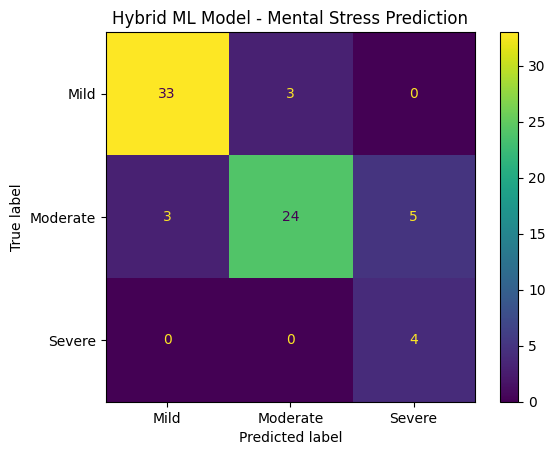

In [41]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=label_encoder.classes_
)

disp.plot()

plt.title(
    "Hybrid ML Model - Mental Stress Prediction"
)

plt.show()

In [42]:
models = {

    "Random Forest": rf_model,

    "Extra Trees": extra_model,

    "Logistic Regression": lr_model
}

In [43]:
results = []

In [44]:
for name, model in models.items():

    pipeline = Pipeline(

        steps=[

            (
                "preprocessor",
                preprocessor
            ),

            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    pred = pipeline.predict(
        X_test
    )

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(
            y_test,
            pred
        ),

        "F1 Score": f1_score(

            y_test,
            pred,

            average="weighted",

            zero_division=0
        )
    })

In [45]:
results.append({

    "Model": "Proposed Hybrid Stacking Model",

    "Accuracy": accuracy,

    "F1 Score": f1
})

In [46]:
results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

print(results_df)

                            Model  Accuracy  F1 Score
1                     Extra Trees  0.916667  0.916448
0                   Random Forest  0.902778  0.902772
2             Logistic Regression  0.861111  0.865741
3  Proposed Hybrid Stacking Model  0.847222  0.854103


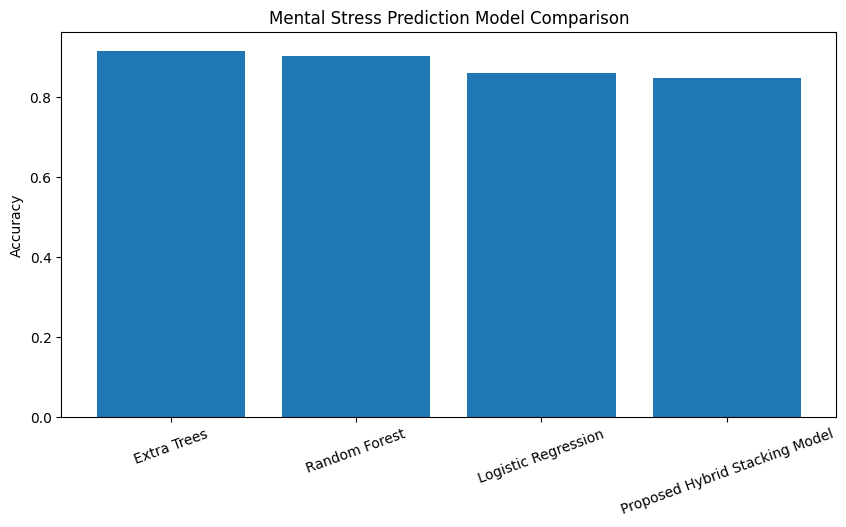

In [47]:
plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.xticks(
    rotation=20
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Mental Stress Prediction Model Comparison"
)

plt.show()

In [48]:
explain_pipeline = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            ExtraTreesClassifier(

                n_estimators=500,

                class_weight="balanced",

                random_state=RANDOM_STATE
            )
        )
    ]
)

In [49]:
explain_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'sleep_hours',
                                                   'sleep_quality',
                                                   'social_media_hours',
                                                   'academic_work_pressure',
                                                   'physical_activity_days',
                                                   'stress_level',
                                                   'anxiety_score',
                                                   'depression_score',
                                                   'work_life_balance',
                                                   'mood_scor...
                                                   'social_support', 'SMBI',
                                                   'Sleep_Deficit',
                                                   'Academic_Stress_Index',
                                                   'Lifestyle_Balance_Index',
                                                   'Psychological_Risk_Index']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'occupation'])])),
                ('model',
                 ExtraTreesClassifier(class_weight='balanced', n_estimators=500,
                                      random_state=42))])

In [50]:
feature_names = explain_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

In [51]:
importance_values = explain_pipeline.named_steps[
    "model"
].feature_importances_

In [52]:
importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance_values
})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False
)

print(
    importance_df.head(15)
)

                          Feature  Importance
17  num__Psychological_Risk_Index    0.159734
15     num__Academic_Stress_Index    0.117232
4     num__academic_work_pressure    0.080154
7              num__anxiety_score    0.067953
6               num__stress_level    0.066746
13                      num__SMBI    0.062157
8           num__depression_score    0.050474
9          num__work_life_balance    0.038068
14             num__Sleep_Deficit    0.037618
16   num__Lifestyle_Balance_Index    0.036522
11       num__concentration_level    0.032301
12            num__social_support    0.030415
1                num__sleep_hours    0.029693
10                num__mood_score    0.028086
2              num__sleep_quality    0.027054


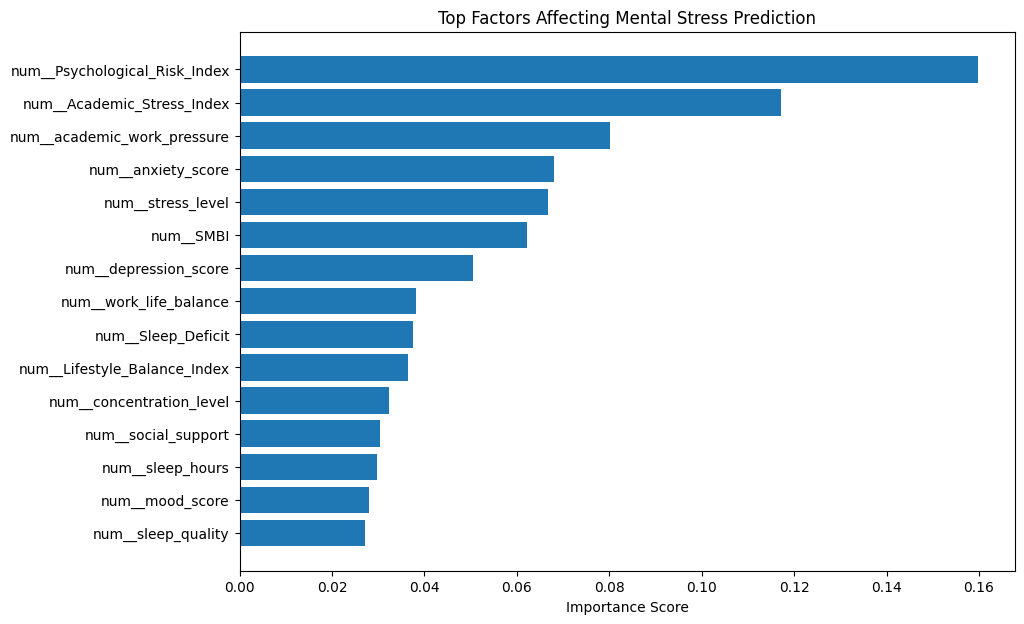

In [53]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(

    top_features["Feature"],

    top_features["Importance"]
)

plt.xlabel(
    "Importance Score"
)

plt.title(
    "Top Factors Affecting Mental Stress Prediction"
)

plt.gca().invert_yaxis()

plt.show()

In [54]:
X_test_processed = explain_pipeline.named_steps[
    "preprocessor"
].transform(
    X_test
)

explain_model = explain_pipeline.named_steps[
    "model"
]

In [55]:
explainer = shap.TreeExplainer(
    explain_model
)

shap_values = explainer.shap_values(
    X_test_processed
)

In [65]:
class_index = 0

# Create a DataFrame from X_test_processed for better compatibility with shap
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)

shap.summary_plot(

    shap_values[class_index],

    X_test_processed, # Use the NumPy array directly for features

    feature_names=feature_names
)

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [61]:
print(label_encoder.classes_)

['Mild' 'Moderate' 'Severe']


In [62]:
def generate_suggestions(

    predicted_severity,
    person_data
):

    suggestions = []

    severity = str(
        predicted_severity
    ).lower()


    # General suggestions based on prediction

    if "mild" in severity:

        suggestions.append(
            "Maintain your current healthy routine and monitor stress regularly."
        )

        suggestions.append(
            "Continue regular sleep, physical activity, and social interaction."
        )


    elif "moderate" in severity:

        suggestions.append(
            "Create a structured daily study schedule and include regular breaks."
        )

        suggestions.append(
            "Practice breathing exercises, mindfulness, or relaxation techniques."
        )

        suggestions.append(
            "Consider discussing persistent stress with a trusted person or university counselor."
        )


    elif "severe" in severity:

        suggestions.append(
            "Consider contacting a qualified mental-health professional or university counseling service."
        )

        suggestions.append(
            "Reach out to a trusted friend, family member, or support person."
        )

        suggestions.append(
            "If you feel in immediate danger or unable to stay safe, seek urgent local emergency support."
        )


    # Personalized rules

    if "sleep_hours" in person_data.index:

        if person_data["sleep_hours"] < 6:

            suggestions.append(
                "Your sleep duration is low. Aim for a more regular and sufficient sleep schedule."
            )


    if "social_media_hours" in person_data.index:

        if person_data["social_media_hours"] > 5:

            suggestions.append(
                "Your social media usage is relatively high. Try setting screen-time limits and taking offline breaks."
            )


    if "physical_activity_days" in person_data.index:

        if person_data["physical_activity_days"] < 2:

            suggestions.append(
                "Your physical activity level is low. Consider gradually adding regular walking or other activities."
            )


    if "academic_work_pressure" in person_data.index:

        if person_data["academic_work_pressure"] >= 4:

            suggestions.append(
                "High academic pressure is detected. Break large tasks into smaller goals and use planned study sessions."
            )


    if "social_support" in person_data.index:

        support_value = person_data["social_support"]

        if support_value <= 2:

            suggestions.append(
                "Your social support appears low. Consider reaching out to trusted friends, family, teachers, or support services."
            )


    if "SMBI" in person_data.index:

        if person_data["SMBI"] > 65:

            suggestions.append(
                "High Social Media Behavior Risk is detected. Reduce prolonged social media exposure and schedule regular digital breaks."
            )


    return list(
        dict.fromkeys(suggestions)
    )

In [63]:
student_number = 0

student = X_test.iloc[
    student_number:student_number + 1
]

In [64]:
prediction_encoded = hybrid_pipeline.predict(
    student
)

prediction = label_encoder.inverse_transform(
    prediction_encoded
)[0]

In [66]:
probabilities = hybrid_pipeline.predict_proba(
    student
)[0]

In [67]:
print("=" * 60)

print(
    "PREDICTED MENTAL STRESS LEVEL:",
    prediction
)

print("\nPrediction Probabilities:")

for class_name, probability in zip(

    label_encoder.classes_,

    probabilities
):

    print(
        f"{class_name}: {probability * 100:.2f}%"
    )

print("=" * 60)

PREDICTED MENTAL STRESS LEVEL: Mild

Prediction Probabilities:
Mild: 94.70%
Moderate: 5.29%
Severe: 0.00%


In [68]:
person_data = student.iloc[0]

suggestions = generate_suggestions(

    prediction,

    person_data
)

print("\nPERSONALIZED DIGITAL HEALTH SUGGESTIONS:\n")

for i, suggestion in enumerate(

    suggestions,

    start=1
):

    print(
        f"{i}. {suggestion}"
    )


PERSONALIZED DIGITAL HEALTH SUGGESTIONS:

1. Maintain your current healthy routine and monitor stress regularly.
2. Continue regular sleep, physical activity, and social interaction.
3. Your physical activity level is low. Consider gradually adding regular walking or other activities.
4. High academic pressure is detected. Break large tasks into smaller goals and use planned study sessions.
5. Your social support appears low. Consider reaching out to trusted friends, family, teachers, or support services.
6. High Social Media Behavior Risk is detected. Reduce prolonged social media exposure and schedule regular digital breaks.


In [69]:
def predict_mental_stress(
    student_input
):

    input_df = pd.DataFrame(
        [student_input]
    )


    # Add engineered features automatically

    if "sleep_hours" in input_df.columns:

        input_df["Sleep_Deficit"] = np.maximum(
            0,
            8 - input_df["sleep_hours"]
        )


    if (
        "academic_work_pressure" in input_df.columns
        and
        "stress_level" in input_df.columns
    ):

        input_df["Academic_Stress_Index"] = (
            input_df["academic_work_pressure"]
            *
            input_df["stress_level"]
        )


    if all(
        col in input_df.columns

        for col in [
            "physical_activity_days",
            "work_life_balance",
            "social_support"
        ]
    ):

        input_df["Lifestyle_Balance_Index"] = (

            input_df["physical_activity_days"]

            +

            input_df["work_life_balance"]

            +

            input_df["social_support"]
        )


    if all(
        col in input_df.columns

        for col in [
            "stress_level",
            "anxiety_score",
            "depression_score"
        ]
    ):

        input_df["Psychological_Risk_Index"] = (

            input_df["stress_level"]

            +

            input_df["anxiety_score"]

            +

            input_df["depression_score"]
        )


    # SMBI

    required_smb = [

        "social_media_hours",
        "stress_level",
        "anxiety_score",
        "depression_score",
        "sleep_quality",
        "mood_score",
        "concentration_level"
    ]


    if all(
        col in input_df.columns
        for col in required_smb
    ):

        temp = input_df.copy()

        # Use original dataset scaling

        for col in required_smb:

            min_val = df[col].min()
            max_val = df[col].max()

            if max_val != min_val:

                temp[col] = (

                    (temp[col] - min_val)

                    /

                    (max_val - min_val)
                )


        input_df["SMBI"] = (

            0.30 * temp["social_media_hours"]

            +

            0.20 * temp["stress_level"]

            +

            0.15 * temp["anxiety_score"]

            +

            0.10 * temp["depression_score"]

            -

            0.10 * temp["sleep_quality"]

            -

            0.10 * temp["mood_score"]

            -

            0.05 * temp["concentration_level"]
        )

        input_df["SMBI"] = (

            (
                input_df["SMBI"]
                -
                df["SMBI"].min()
            )

            /

            (
                df["SMBI"].max()
                -
                df["SMBI"].min()
            )

        ) * 100


    # Ensure same feature order

    input_df = input_df[
        X.columns
    ]


    prediction_encoded = hybrid_pipeline.predict(
        input_df
    )

    prediction = label_encoder.inverse_transform(
        prediction_encoded
    )[0]


    probabilities = hybrid_pipeline.predict_proba(
        input_df
    )[0]


    suggestions = generate_suggestions(

        prediction,

        input_df.iloc[0]
    )


    return {

        "Predicted Stress Level": prediction,

        "Prediction Confidence": {

            class_name: round(
                probability * 100,
                2
            )

            for class_name, probability

            in zip(

                label_encoder.classes_,

                probabilities
            )
        },

        "Personalized Suggestions": suggestions
    }

In [71]:
example_student = {

    "age": 22,

    "gender": "Female",

    "occupation": "Student", # Added 'occupation'

    "sleep_hours": 5,

    "sleep_quality": 2,

    "social_media_hours": 7,

    "academic_work_pressure": 5,

    "physical_activity_days": 1,

    "stress_level": 5,

    "anxiety_score": 4,

    "depression_score": 3,

    "work_life_balance": 2,

    "mood_score": 2,

    "concentration_level": 2,

    "social_support": 2
}

result = predict_mental_stress(
    example_student
)

print(result)

{'Predicted Stress Level': 'Severe', 'Prediction Confidence': {'Mild': np.float64(0.0), 'Moderate': np.float64(0.0), 'Severe': np.float64(100.0)}, 'Personalized Suggestions': ['Consider contacting a qualified mental-health professional or university counseling service.', 'Reach out to a trusted friend, family member, or support person.', 'If you feel in immediate danger or unable to stay safe, seek urgent local emergency support.', 'Your sleep duration is low. Aim for a more regular and sufficient sleep schedule.', 'Your social media usage is relatively high. Try setting screen-time limits and taking offline breaks.', 'Your physical activity level is low. Consider gradually adding regular walking or other activities.', 'High academic pressure is detected. Break large tasks into smaller goals and use planned study sessions.', 'Your social support appears low. Consider reaching out to trusted friends, family, teachers, or support services.']}
